# Đánh giá mô hình RAG bằng phương pháp LLM-as-a-Judge

Notebook này hướng dẫn cách sử dụng LLMs (Gemini pro) để đánh giá hiệu suất tổng thể của mô hình RAG cho các môn đại cương.
Mô hình sẽ đánh giá qua các Metrics sau:
- Faithfullness
- Relevance
- Fluency

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
%matplotlib inline

from retriever.hybrid_search import hybrid_retriever
from utils.save_chunks_json import save_chunks_to_json
from utils.load_chunks_json import load_chunks_from_json
from agent import generate_answer, get_router
from retriever.cache_data import get_gemini_model

import pandas as pd
from tqdm import tqdm
import json
import pandas as pd
import re
import matplotlib.pyplot as plt

c:\Users\dhdnc\OneDrive\ドキュメント\GitHub\RAG_GeneralSubject\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Xây dựng các hàm cần thiết cho quá trình đánh giá mô hình

In [2]:
# Hàm sử dụng RAG để tạo file đánh giá, sẽ trả về các tham số cần thiết cho việc đánh giá mô hình
def query_rag(eval_data, file_path):

    data = []

    for question, ground_truth in zip(eval_data['question'], eval_data['ground_truth_answer']):

        #Phần xử lý truy vấn mô hình RAG để lấy context và trả về kết quả
        context = hybrid_retriever(question, 'gemini-2.5-flash', 10)
        router = get_router(question, 'gemini-2.5-flash')
        answer = generate_answer(question, context, router, model_choice='gemini-2.5-flash')

        data.append({
            'question': question,
            'answer': answer,
            'contexts': context,
            'ground_truth': ground_truth
        })
        
    save_chunks_to_json(data, file_path)

    return data

In [3]:
#Hàm để trả về 1 prompt đánh giá mô hình RAG kết hợp với các thông tin cần thiết
def format_prompt(question: str, answer: str, ground_truth: str, contexts: list) -> str:
    """
    Tạo prompt tiếng Việt để đánh giá câu trả lời RAG bằng LLM, yêu cầu trả về dict Python.
    """
    context_str = "\n\n".join([f"[{ctx['id']}]: {ctx['content']}" for ctx in contexts])
    prompt = f"""
    Bạn là một chuyên gia đánh giá hệ thống hỏi đáp dựa trên RAG (Retrieval-Augmented Generation), hãy dựa vào các thông tin đã được cung cấp
    để đánh giá cau trả lời của mô hình. Hãy đánh giá một cách công bằng và khách quan, dựa trên các tiêu chí đã được cung cấp.

    ### Câu hỏi:
    {question}

    ### Câu trả lời của mô hình:
    {answer}

    ### Câu trả lời đúng (ground truth):
    {ground_truth}

    ### Các đoạn văn bản được truy xuất (contexts):
    {context_str}

    ---

    ### Nhiệm vụ:
    1. Đánh giá độ chính xác (**correctness**) của câu trả lời so với ground truth (thang điểm 0-5).
    2. Đánh giá độ trung thực (**faithfulness**) của câu trả lời với các đoạn context (thang điểm 0-5).
    3. Đánh giá mức độ liên quan (**relevance**) của câu trả lời với chính câu hỏi đã đưa ra (thang điểm 0-5).
    4. Nhận xét ngắn gọn về câu trả lời.

    **Chỉ trả lời bằng một dict Python hợp lệ, không bao gồm bất kỳ chú thích, tiêu đề hay khối mã nào. Không sử dụng dấu ``` hoặc từ 'json'.**

    Định dạng trả về như sau (không thêm gì ngoài nội dung này), đây là định dạng String:

    {{
        "correctness": "int",  
        "faithfulness": "int",  
        "relevance": "int",  
        "comment": "string" 
    }}
    """
    return prompt

In [4]:
#Bởi vì kết quả trả về là một chuỗi JSON được bọc trong code block, ta cần parse nó để lấy các trường mong muốn
#Hàm này sẽ nhận vào chuỗi JSON được bọc trong code block và trả về các trường mong muốn: correctness, faithfulness, relevance, comment
def parse_evaluation_block(text: str):
    """
    Nhận vào chuỗi chứa JSON được bọc bởi code block (ví dụ ```json ... ```)
    Trả về 4 tham số: correctness, faithfulness, relevance, comment
    """
    # Bước 1: Tách phần JSON khỏi code block
    match = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, re.DOTALL)
    if not match:
        raise ValueError("Không tìm thấy đoạn JSON trong code block.")
    
    json_str = match.group(1)

    # Bước 2: Parse JSON thành dict
    try:
        data = json.loads(json_str)
    except json.JSONDecodeError as e:
        raise ValueError(f"Lỗi khi đọc JSON: {e}")
    
    # Bước 3: Lấy các trường mong muốn
    try:
        correctness = data["correctness"]
        faithfulness = data["faithfulness"]
        relevance = data["relevance"]
        comment = data["comment"]
    except KeyError as e:
        raise KeyError(f"Thiếu trường trong JSON: {e}")
    
    return correctness, faithfulness, relevance, comment

In [5]:
import time
from tqdm import tqdm
import json
import pandas as pd

def evaluate_rag(file_path: str, output_path: str = None):
    """
    Đánh giá mô hình RAG bằng Gemini (LLM-based Evaluation)
    Không giới hạn retry nếu lỗi 503 (mô hình quá tải)
    :param file_path: Đường dẫn file JSON chứa các câu hỏi + context + answer
    :param output_path: (Optional) Lưu kết quả ra JSON
    :return: df_result, avg_correctness, avg_faithfulness, avg_relevance
    """
    client = get_gemini_model()
    data = load_chunks_from_json(file_path)

    results = []
    correctness_list = []
    faithfulness_list = []
    relevance_list = []

    for idx, item in enumerate(tqdm(data, desc="Đang đánh giá RAG")):
        question = item["question"]
        answer = item["answer"]
        ground_truth = item["ground_truth"]
        contexts = item["contexts"]
        prompt = format_prompt(question, answer, ground_truth, contexts)

        attempt = 0
        while True:
            try:
                response = client.models.generate_content(
                    model="gemini-2.5-pro",
                    contents=prompt,
                )
                content = response.text.strip()
                correctness, faithfulness, relevance, comment = parse_evaluation_block(content)

                results.append({
                    "question": question,
                    "answer": answer,
                    "ground_truth": ground_truth,
                    "correctness": correctness,
                    "faithfulness": faithfulness,
                    "relevance": relevance,
                    "comment": comment
                })

                correctness_list.append(correctness)
                faithfulness_list.append(faithfulness)
                relevance_list.append(relevance)
                break  # break while loop if successful

            except Exception as e:
                if "503" in str(e):
                    wait_time = min(60, 2 ** attempt)
                    print(f"[{idx}] Lỗi 503 - quá tải mô hình. Đợi {wait_time}s rồi thử lại (lần {attempt + 1})...")
                    time.sleep(wait_time)
                    attempt += 1
                else:
                    print(f"[{idx}] Lỗi không phải 503: {e}")
                    break  # lỗi khác thì bỏ mẫu này luôn

    df_result = pd.DataFrame(results)

    avg_correctness = sum(correctness_list) / len(correctness_list) if correctness_list else 0
    avg_faithfulness = sum(faithfulness_list) / len(faithfulness_list) if faithfulness_list else 0
    avg_relevance = sum(relevance_list) / len(relevance_list) if relevance_list else 0

    if output_path:
        save_chunks_to_json(df_result.to_dict(orient='records'), output_path)

    return df_result, avg_correctness, avg_faithfulness, avg_relevance


## ***Đánh giá môn Lịch Sử Đảng***

In [6]:
# LSD_df_res, LSD_correctness, LSD_faithfulness, LSD_relevance = evaluate_rag(r'./eval_data/LSD_eval_data.json', output_path=r'./eval_result/LSD_eval_result.json')

## ***Đánh giá môn Triết Học***

In [7]:
# TrietHoc_df_res, TrietHoc_correctness, TrietHoc_faithfulness, TrietHoc_relevance = evaluate_rag(r'./eval_data/TrietHoc_eval_data.json', output_path=r'./eval_result/TreitHoc_eval_result.json')

# Tính AVG Correctness, Faithfilness, Relevance của Model

In [8]:
#Đọpc qua kết quả đánh giá của các môn từ các file JSON đã lưu
LSD_rest = load_chunks_from_json(r'./eval_result/LSD_eval_result.json')
TrietHoc_rest = load_chunks_from_json(r'./eval_result/TrietHoc_eval_result.json')

eval_results = LSD_rest + TrietHoc_rest
len(eval_results)

139

In [9]:
def tinh_diem_eval(eval_results):
    """
    Tính điểm đánh giá trung bình từ danh sách kết quả đánh giá.
    :param eval_results: List các dict có trường 'correctness', 'faithfulness', 'relevance'
    :return: dict chứa các điểm trung bình
    """
    if not eval_results:
        return {
            "avg_correctness": 0,
            "avg_faithfulness": 0,
            "avg_relevance": 0,
            "avg_total": 0
        }

    total_correctness = sum(item.get("correctness", 0) for item in eval_results)
    total_faithfulness = sum(item.get("faithfulness", 0) for item in eval_results)
    total_relevance = sum(item.get("relevance", 0) for item in eval_results)
    total = len(eval_results)

    avg_correctness = total_correctness / total
    avg_faithfulness = total_faithfulness / total
    avg_relevance = total_relevance / total
    avg_total = (avg_correctness + avg_faithfulness + avg_relevance) / 3

    return {
        "avg_correctness": round(avg_correctness, 3),
        "avg_faithfulness": round(avg_faithfulness, 3),
        "avg_relevance": round(avg_relevance, 3),
        "avg_total": round(avg_total, 3)
    }


In [10]:
#In ra điểm của model
model_score = tinh_diem_eval(eval_results)
print(model_score)

{'avg_correctness': 4.619, 'avg_faithfulness': 4.993, 'avg_relevance': 4.899, 'avg_total': 4.837}


In [11]:
def plot_eval_results(score_dict, title="Kết quả đánh giá mô hình RAG", path=None):
    """
    Vẽ biểu đồ thanh cho các chỉ số đánh giá. Có thể lưu ra file nếu cung cấp path.
    :param score_dict: Dict trả về từ tinh_diem_eval()
    :param title: Tiêu đề biểu đồ
    :param path: Đường dẫn lưu file ảnh (nếu có), ví dụ "output/ketqua.png"
    """
    metrics = ['correctness', 'faithfulness', 'relevance', 'total']
    scores = [
        score_dict.get("avg_correctness", 0),
        score_dict.get("avg_faithfulness", 0),
        score_dict.get("avg_relevance", 0),
        score_dict.get("avg_total", 0)
    ]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(metrics, scores, color=["#007acc", "#32a852", "#ffa500", "#ff4d4d"])
    
    # Gắn nhãn giá trị trên đầu cột
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 3),
                 ha='center', va='bottom', fontsize=10)

    plt.ylim(0, 5.2)
    plt.title(title, fontsize=13)
    plt.ylabel("Điểm trung bình (0-5)")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()

    if path:
        plt.savefig(path, dpi=300)
    
    plt.show()


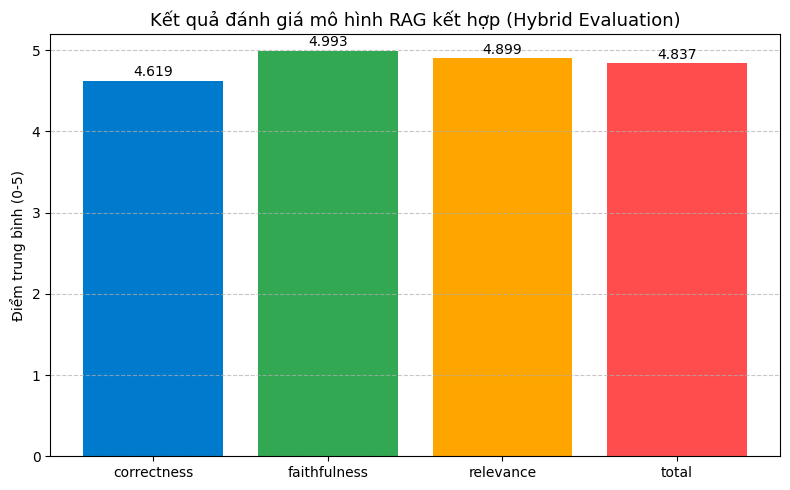

In [12]:
plot_eval_results(model_score, title="Kết quả đánh giá mô hình RAG kết hợp (Hybrid Evaluation)", path="./eval_result/hybrid_eval_overall.png")

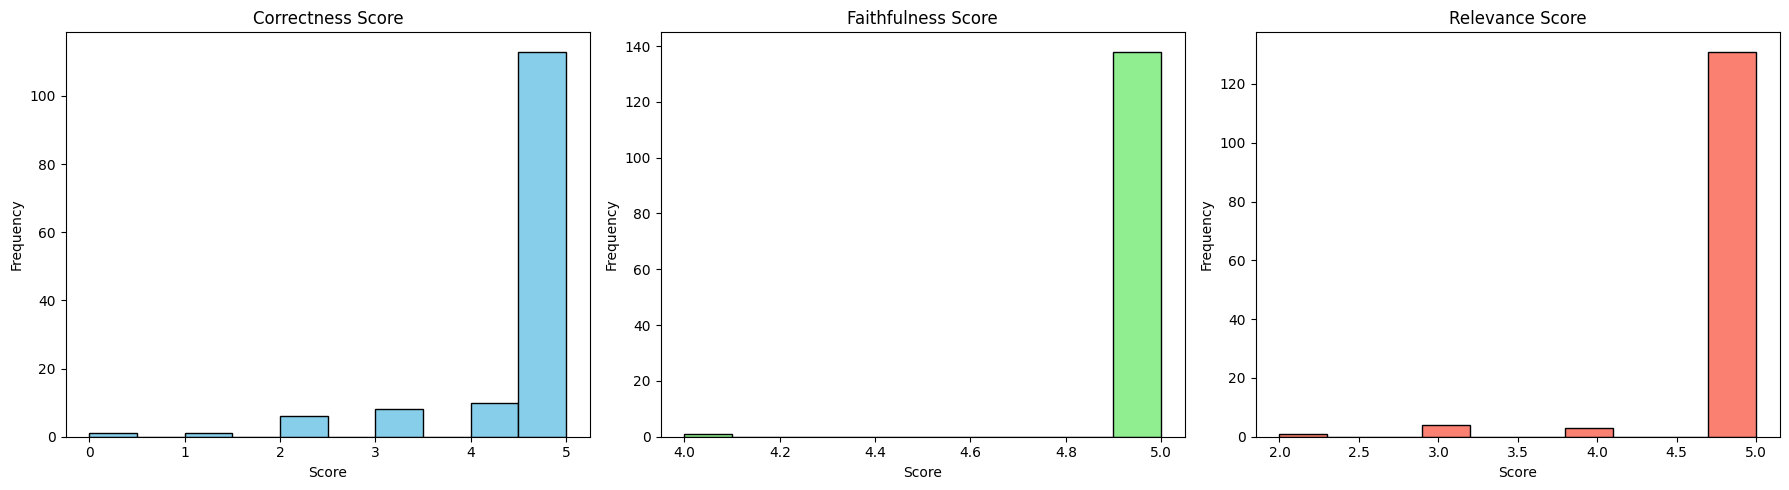

In [13]:
import matplotlib.pyplot as plt

def plot_eval_scores_subplots(eval_results, path=None):
    """
    Vẽ 3 biểu đồ histogram cho các điểm: correctness, faithfulness, relevance.
    Có thể lưu ảnh ra file nếu cung cấp path.
    
    :param eval_results: List[Dict], mỗi dict chứa các điểm số.
    :param path: Đường dẫn lưu ảnh, ví dụ 'output/eval_histograms.png'. Nếu None thì không lưu.
    """
    # Trích các điểm số
    correctness_scores = [res["correctness"] for res in eval_results]
    faithfulness_scores = [res["faithfulness"] for res in eval_results]
    relevance_scores = [res["relevance"] for res in eval_results]

    # Tạo figure và 3 subplots theo hàng ngang
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot từng biểu đồ histogram
    axes[0].hist(correctness_scores, bins=10, color='skyblue', edgecolor='black')
    axes[0].set_title('Correctness Score')
    axes[0].set_xlabel('Score')
    axes[0].set_ylabel('Frequency')

    axes[1].hist(faithfulness_scores, bins=10, color='lightgreen', edgecolor='black')
    axes[1].set_title('Faithfulness Score')
    axes[1].set_xlabel('Score')
    axes[1].set_ylabel('Frequency')

    axes[2].hist(relevance_scores, bins=10, color='salmon', edgecolor='black')
    axes[2].set_title('Relevance Score')
    axes[2].set_xlabel('Score')
    axes[2].set_ylabel('Frequency')

    # Căn chỉnh bố cục
    plt.tight_layout()

    # Lưu ảnh nếu có đường dẫn
    if path:
        plt.savefig(path, dpi=300)

    # Hiển thị
    plt.show()
plot_eval_scores_subplots(eval_results, path="./eval_result/hybrid_eval_individual.png")